№2.1

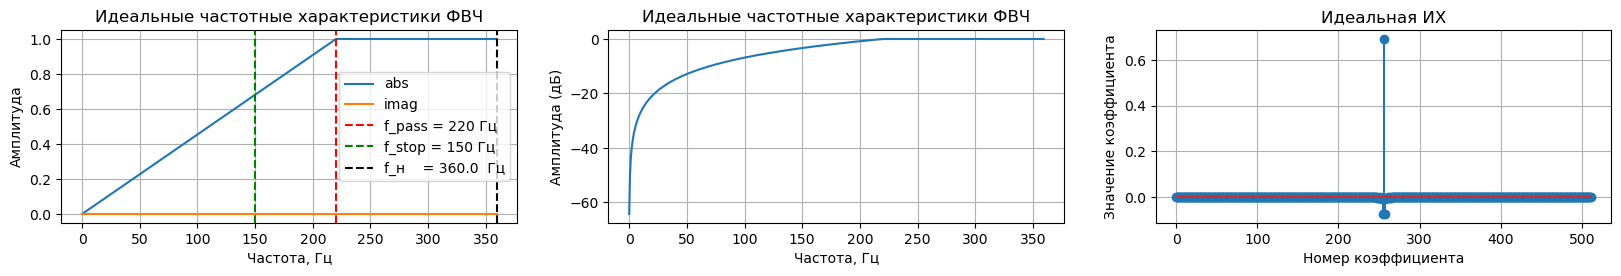

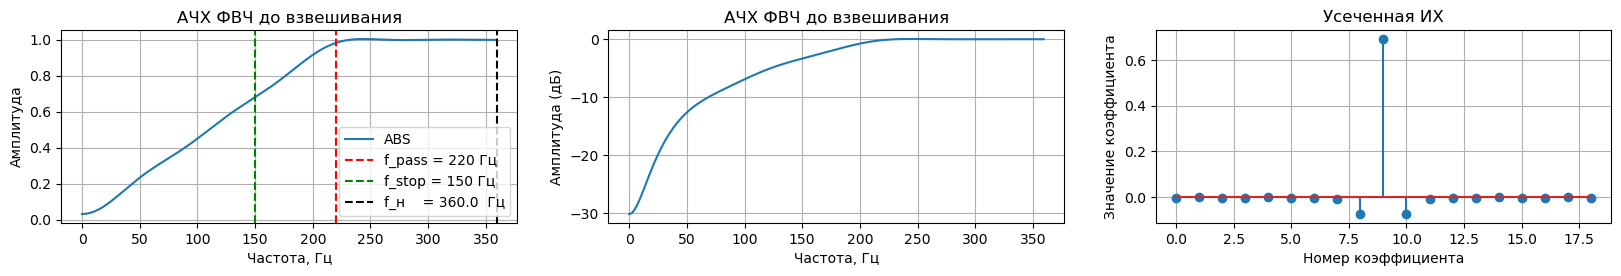

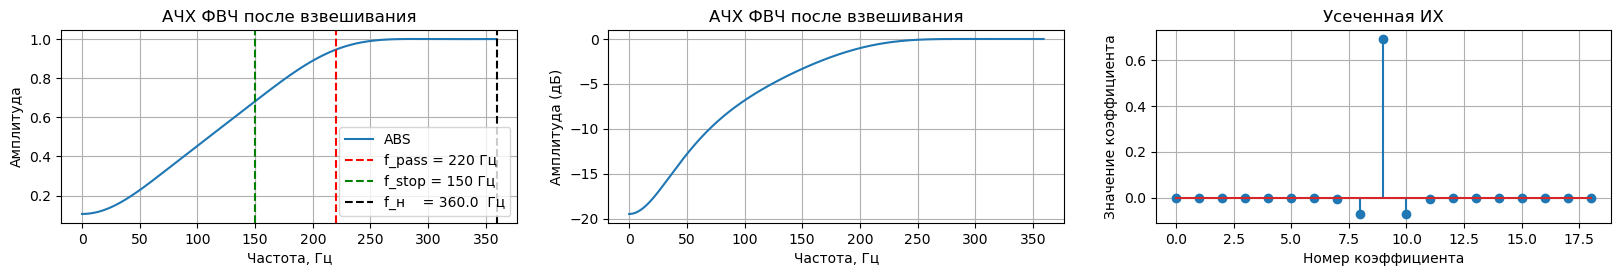

In [121]:
import numpy as np
from scipy.signal import firwin2, freqz, windows
from scipy.signal.windows import hann
import matplotlib.pyplot as plt

# Требования: 
# спроектировать ФНЧ с частотой среза, равной 0.5*fн (fн - частота Найквиста), с частотой запирания, равной fн
# Порядок фильтра Nf = 20

# Параметры фильтра
Nf = 18 + 1  # Количество коэффициентов фильтра (порядок фильтра + 1)

f_s = 720
f_pass = 220
f_stop = 150

# Для демонстрации эффекта использования оконных функций рассматриваются 2 примера: 
# - с использованием прямоугольного окна
# - с использованием окна Хэмминга
window_types = ['boxcar', 'boxcar', 'hann']
num_coefs = [1025, Nf, Nf]
titles = [['Идеальные частотные характеристики ФВЧ', 'Идеальная ИХ'], 
          ['АЧХ ФВЧ до взвешивания',                 'Усеченная ИХ'],
          ['АЧХ ФВЧ после взвешивания',              'Усеченная ИХ']]

for i in range(len(window_types)):

    # Создание FIR фильтра низких частот
    filter_coefs = firwin2(num_coefs[i], [0.0, f_pass, f_s/2], [0.0, 1.0, 1.0], window=window_types[i], fs=f_s)
    
    # Анализ характеристик фильтра
    w, h = freqz(filter_coefs)

    # ОБПФ
    ideal_IH = np.fft.ifft(h).real

    # Усечение
    if i == 0:
        ideal_IH_shifted = ideal_IH[1025//4 - Nf//2 : 1025//4 + Nf//2 + 1]
        window = hann(Nf, sym=True)
        IH_windowed = ideal_IH_shifted * window
    
    # Визуализация амплитудной характеристики фильтра
    plt.figure(figsize=(20, 2.5))
    plt.subplot(1,3,1)
    if i == 0:
        plt.plot(w/np.pi*f_s/2, np.abs(h),  label='abs')
        plt.plot(w/np.pi*f_s/2, np.imag(h), label='imag')
    else:
        plt.plot(w/np.pi*f_s/2, abs(h),     label='ABS')
    plt.axvline(f_pass, color='r', linestyle='--', label=f'f_pass = {f_pass} Гц')
    plt.axvline(f_stop, color='g', linestyle='--', label=f'f_stop = {f_stop} Гц')
    plt.axvline(f_s/2,  color='k', linestyle='--', label=f'f_н    = {f_s/2}  Гц')
    plt.legend()
    plt.title(titles[i][0])
    plt.xlabel('Частота, Гц')
    plt.ylabel('Амплитуда')
    plt.grid(True)
    
    plt.subplot(1,3,2)
    plt.plot(w/np.pi*f_s/2, 20 * np.log10(abs(h)))
    plt.title(titles[i][0])
    plt.xlabel('Частота, Гц')
    plt.ylabel('Амплитуда (дБ)')
    plt.grid(True)
    
    # Визуализация импульсной характеристики фильтра
    plt.subplot(1,3,3)
    if i == 0:
        plt.stem(ideal_IH)
    if i == 1:
        plt.stem(ideal_IH_shifted)
    if i == 2:
        plt.stem(IH_windowed)
    plt.title(titles[i][1])
    plt.xlabel('Номер коэффициента')
    plt.ylabel('Значение коэффициента')
    plt.grid(True)
    
    plt.show()


№2.2

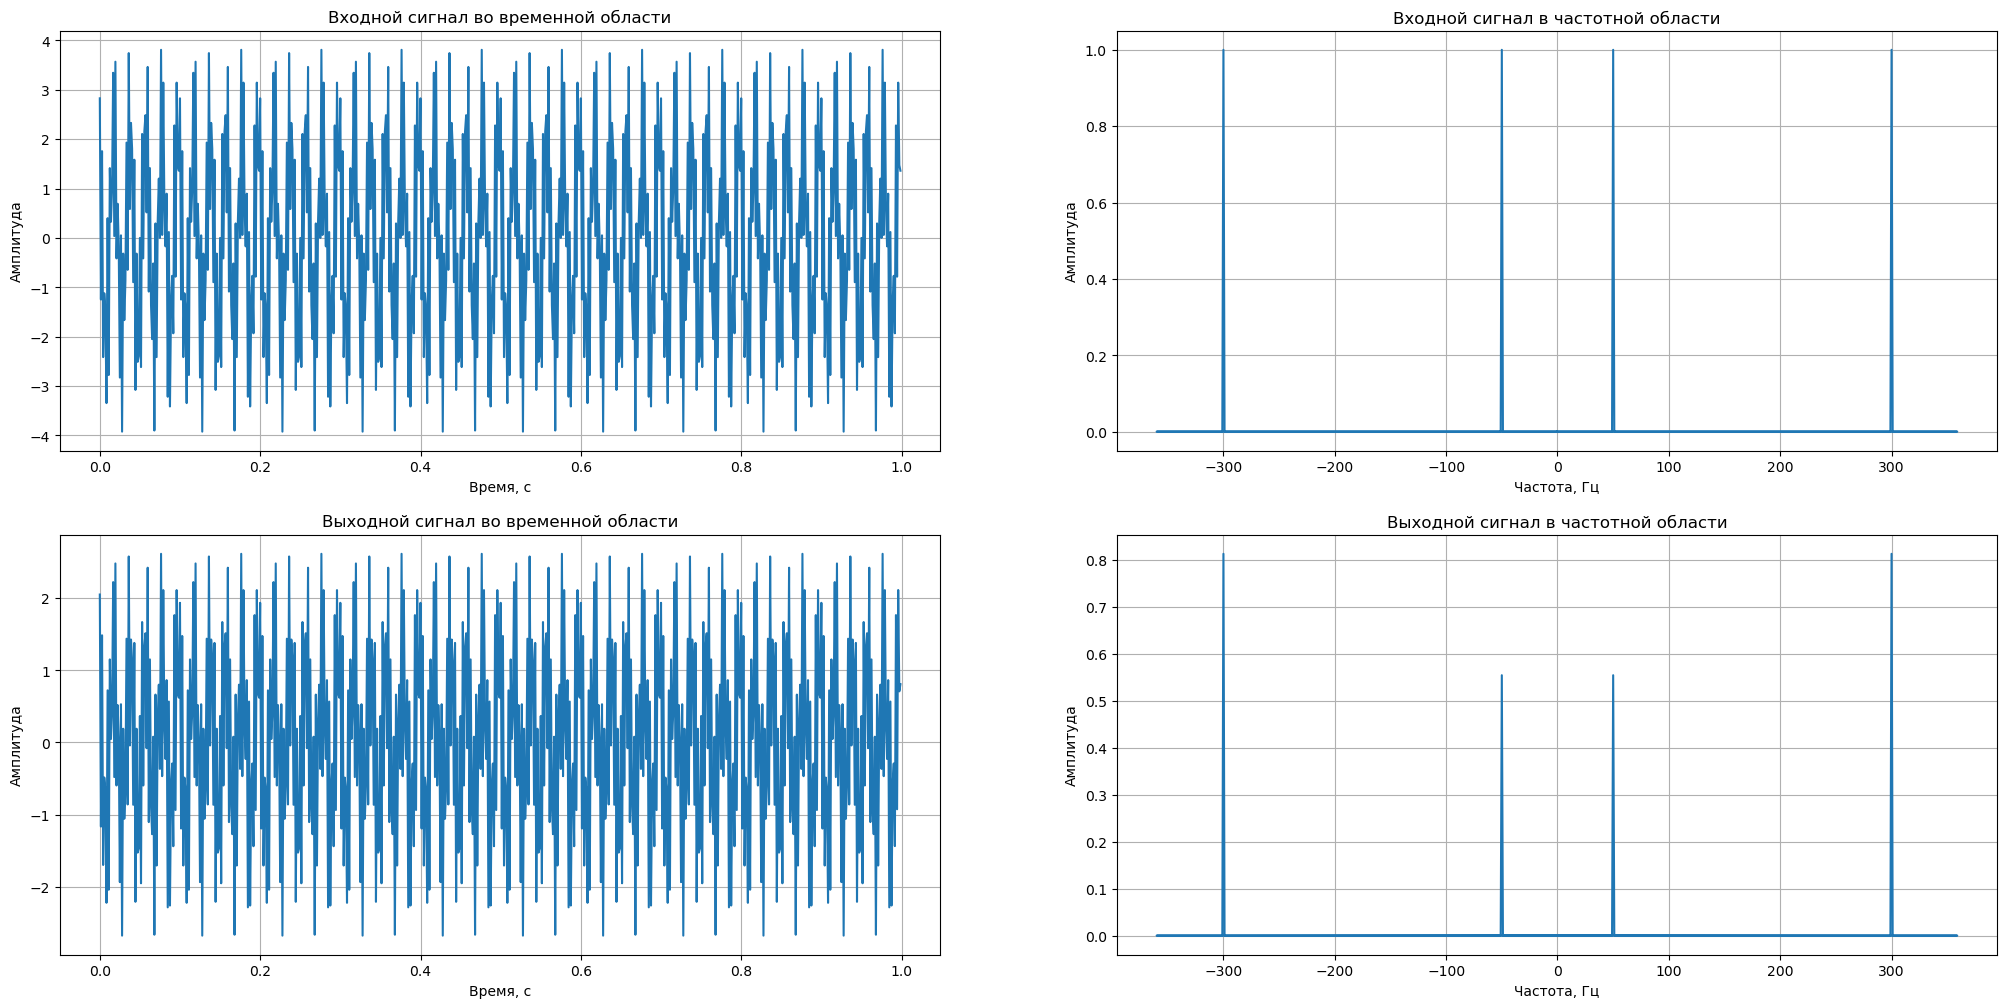

In [120]:
from scipy import fftpack

Amp = 18 % 4                # Амплитуда сигнала
f01  = 300                    # Частота 1 гармонического сигнала в Гц
f02  = 50                    # Частота 2 гармонического сигнала в Гц
phi0 = 3*np.pi/4            # Начальная фаза гармонического сигнала
fs = 720                     # Частота дискретизации в Гц
tau = 1                      # Длительность сигналов
N = 720                      # Размер ДПФ (количество гармоник)

# Оси времени и частоты
t = np.linspace(0, tau, N, endpoint = False)
f = fftpack.fftfreq(N) * fs

# Генерация гармонического сигнала
x = Amp * (np.sin(2 * np.pi * f01 * t + phi0) + np.sin(2 * np.pi * f02 * t + phi0))

y = np.convolve(x, IH_windowed, mode='same')

A_x = np.abs(fftpack.fft(x))
A_y = np.abs(fftpack.fft(y))

plt.figure(figsize=(25, 12))
plt.subplot(2,2,1)
plt.plot(t, x,     label='ABS')
plt.title("Входной сигнал во временной области")
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.subplot(2,2,2)
plt.plot(f, A_x / N,     label='ABS')
# plt.axvline(f01, color='r', linestyle='--', label=f'f01 = {f01} Гц')
# plt.axvline(f02, color='g', linestyle='--', label=f'f02 = {f02} Гц')
plt.title("Входной сигнал в частотной области")
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда')
plt.grid(True)

# Визуализация импульсной характеристики фильтра
plt.subplot(2,2,3)
plt.plot(t, y,     label='ABS')
plt.title("Выходной сигнал во временной области")
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.subplot(2,2,4)
plt.plot(f, A_y / N,     label='ABS')
# plt.axvline(f01, color='r', linestyle='--', label=f'f01 = {f01} Гц')
# plt.axvline(f02, color='g', linestyle='--', label=f'f02 = {f02} Гц')
plt.title("Выходной сигнал в частотной области")
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.show()

Дополнительное задание №2

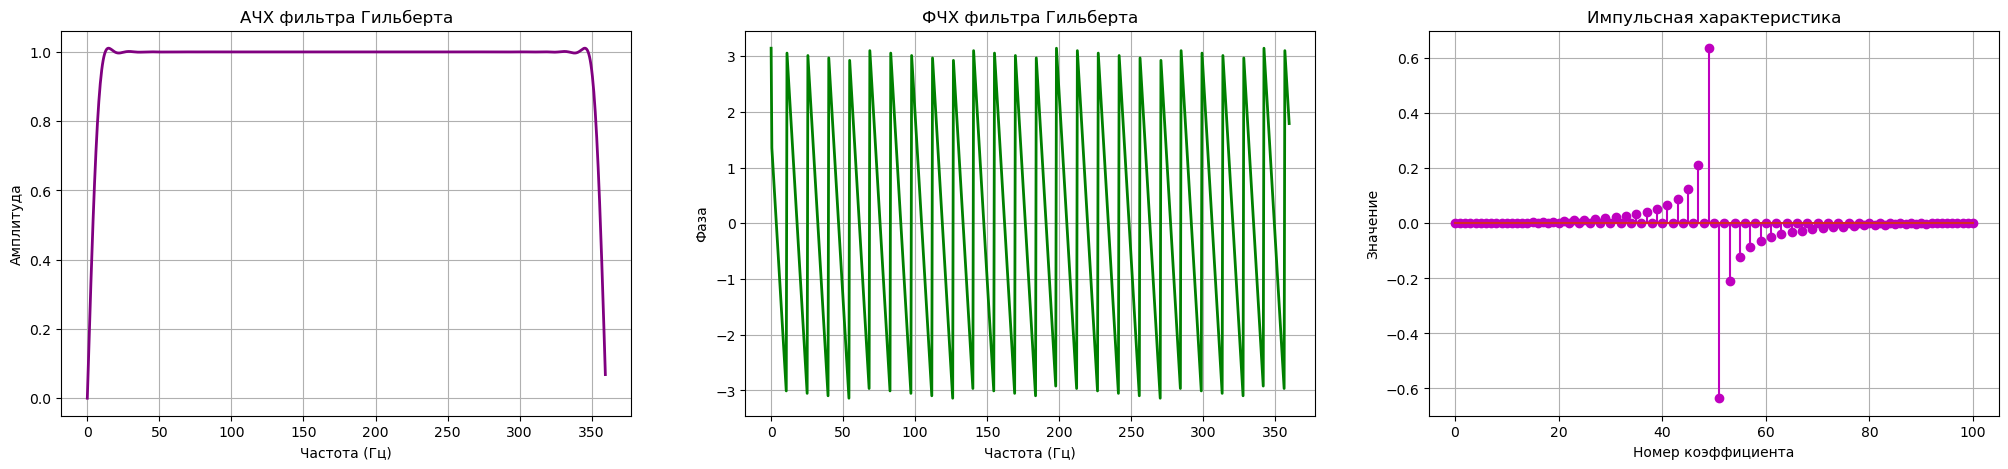

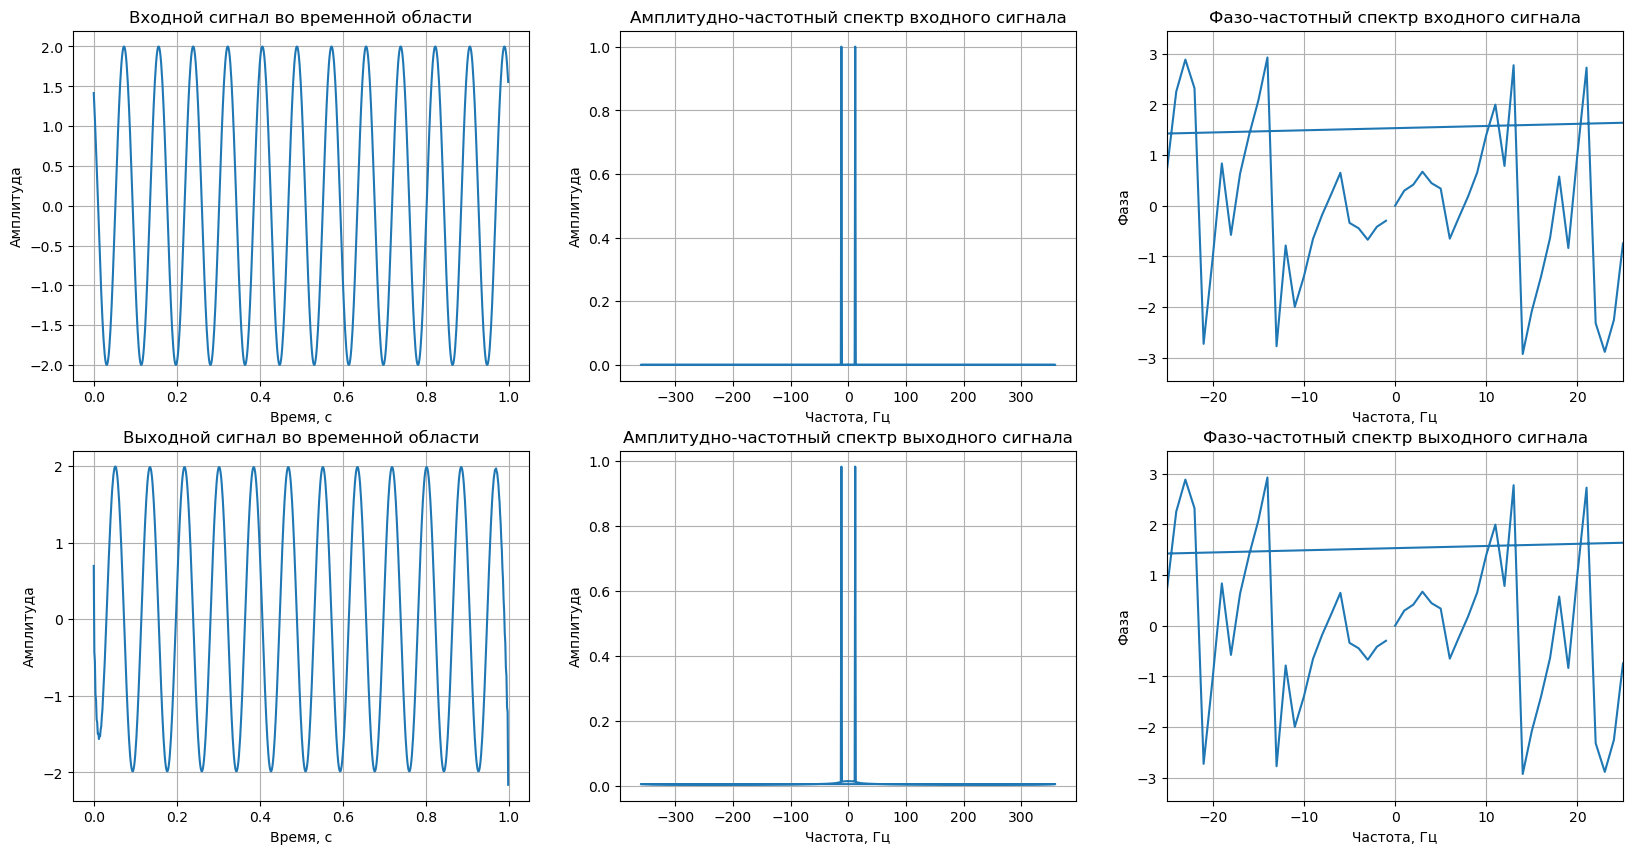

In [181]:
Nf = 100 + 1
f_s = 720

filter_hilbert_coefs = firwin2(Nf, [0.0, 0.0000005 * f_s/2, 0.9999995 * f_s/2, f_s/2], 
                                   [0.0, 1.0, 1.0, 0.0], window='hann', antisymmetric=True, fs=f_s)

w_h, h_h = freqz(filter_hilbert_coefs, worN=f_s,fs=f_s)

# ФЧХ фильтра
P = np.angle(h_h)
A = np.abs(h_h)

Amp = 18 % 4                # Амплитуда сигнала
f0  = 12                    # Частота гармонического сигнала в Гц
phi0 = 3*np.pi/4            # Начальная фаза гармонического сигнала
fs = 720                     # Частота дискретизации в Гц
tau = 1                      # Длительность сигналов
N = 720                      # Размер ДПФ (количество гармоник)

# Оси времени и частоты
t = np.linspace(0, tau, N, endpoint = False)
f = fftpack.fftfreq(N) * fs

# Генерация гармонического сигнала
x = Amp * np.sin(2 * np.pi * f0 * t + phi0)

# Фильтруем сигнал
y = np.convolve(x, filter_hilbert_coefs, mode='same')

# Амплитудно-частотные спектры сигналов
A_x = np.abs(fftpack.fft(x))
A_y = np.abs(fftpack.fft(y))

# Фазо-частотные спектры сигналов
P_x = np.angle(fftpack.fft(x))
P_y = np.angle(fftpack.fft(x))

plt.figure(figsize=(25, 5))
plt.subplot(1, 3, 1)
plt.plot(w_h, A, color='purple', linewidth=2)
plt.title('АЧХ фильтра Гильберта')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(w_h, P, color='green', linewidth=2)
plt.title('ФЧХ фильтра Гильберта')
plt.xlabel('Частота (Гц)')
plt.ylabel('Фаза')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.stem(filter_hilbert_coefs, linefmt='m-', markerfmt='mo')
plt.title('Импульсная характеристика')
plt.xlabel('Номер коэффициента')
plt.ylabel('Значение')
plt.grid(True)

plt.figure(figsize=(20, 10))
plt.subplot(2, 3, 1)
plt.plot(t, x)
plt.title("Входной сигнал во временной области")
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.subplot(2, 3, 2)
plt.plot(f, A_x / N)
plt.title("Амплитудно-частотный спектр входного сигнала")
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.subplot(2, 3, 3)
plt.plot(f, P_x)
plt.xlim(-25, 25)
plt.title("Фазо-частотный спектр входного сигнала")
plt.xlabel('Частота, Гц')
plt.ylabel('Фаза')
plt.grid(True)

plt.subplot(2, 3, 4)
plt.plot(t, y)
plt.title("Выходной сигнал во временной области")
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.subplot(2, 3, 5)
plt.plot(f, A_y / N)
plt.title("Амплитудно-частотный спектр выходного сигнала")
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.subplot(2, 3, 6)
plt.plot(f, P_y)
plt.xlim(-25, 25)
plt.title("Фазо-частотный спектр выходного сигнала")
plt.xlabel('Частота, Гц')
plt.ylabel('Фаза')
plt.grid(True)

plt.show()